## TASK 1: Netflix Data Cleaning & Preparation
## Description : Prepare and organize the Netflix dataset for business analytics and reporting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

### Step 1: Import the dataset using Python and Pandas.

In [2]:
df=pd.read_csv("/kaggle/input/datasets/fatmakaplan35/netflix-dataset/Dataset.csv")
print("Original Data Size: " , df.shape)

Original Data Size:  (8790, 10)


### Step 2: Identify and handle missing values.

In [3]:
## Missing values numbers
print("Missing values numbers: ", df.isnull().sum())

Missing values numbers:  show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


### Step 3: Remove duplicate records and formatting inconsistencies

In [4]:
df=df.drop_duplicates()

In [5]:
# Strip leading and trailing whitespaces from all string (object) columns
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

### Step 4: Standardize columns such as Country, Rating and Type

In [6]:
if 'Country' in df.columns:
    # Standardize capitalization (e.g., 'united states' -> 'United States')
    df['Country'] = df['Country'].str.title()
    # Map common variations to a single standard name
    country_corrections = {'Usa': 'United States', 'U.S.A.': 'United States', 'Uk': 'United Kingdom'}
    df['Country'] = df['Country'].replace(country_corrections)

if 'Type' in df.columns:
    # Convert 'Type' to lowercase for consistency
    df['Type'] = df['Type'].str.lower()

if 'Rating' in df.columns:
    # Convert 'Rating' to a numeric type, coercing invalid text/symbols into NaN
    df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
    
    # Drop any new NaN values created by the coercion
    df = df.dropna(subset=['Rating'])

### Step 5: Export the cleaned dataset for analysis

In [7]:
df.to_csv('cleaned_dataset.csv', index=False)

print("\nData cleaning complete. Saved as 'cleaned_dataset.csv'.")
print("Cleaned Dataset Shape:", df.shape)


Data cleaning complete. Saved as 'cleaned_dataset.csv'.
Cleaned Dataset Shape: (8790, 10)


## Task 2 – Content Type Analysis Dashboard

### Description : Analyze the distribution of Movies and TV Shows available on Netflix.

### Step 1: Load the cleaned dataset.

In [8]:
df=pd.read_csv("/kaggle/input/datasets/fatmakaplan35/netflix-dataset/cleaned_dataset.csv")

In [9]:
# Ensure the 'Type' column is in a consistent format (just in case)
if 'type' in df.columns:
    df['type'] = df['type'].str.title() # Capitalizes 'Movie' and 'Tv Show'

### Step 2: Calculate the total number of Movies and TV shows

In [10]:
# Count the occurrences of each content type
content_counts = df['type'].value_counts()

print("--- Total Counts ---")
print(content_counts)
print("-" * 20)

--- Total Counts ---
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64
--------------------


### Step 3: Create visualizations for content distribution

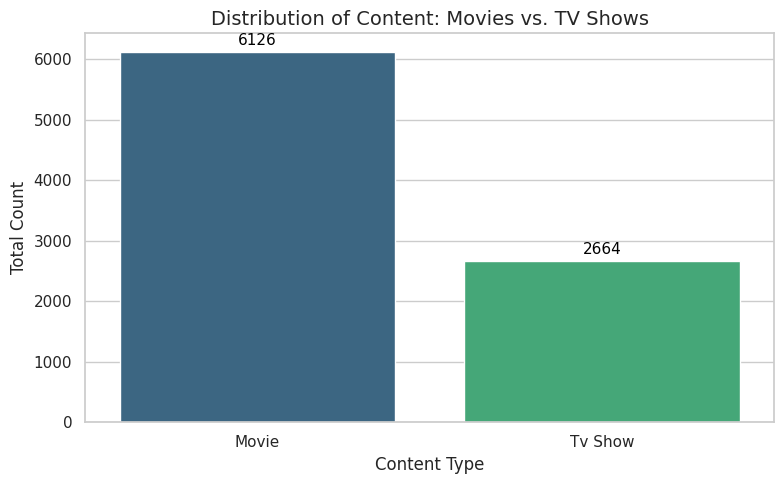

In [11]:
sns.set_theme(style="whitegrid")


plt.figure(figsize=(8,5))
ax=sns.barplot(x=content_counts.index , y=content_counts.values , palette="viridis")
plt.title('Distribution of Content: Movies vs. TV Shows' ,fontsize=14)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)

## Add data labels on top of the bars

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2.,p.get_height()),
               ha='center', va='bottom',fontsize=11, color='black', xytext=(0,3),
               textcoords='offset points')

plt.tight_layout()
plt.show()

### Step 4: Compare content proportions

In [12]:
# Calculate the percentage of each type
content_proportions = df['type'].value_counts(normalize=True) * 100

In [13]:
print("\n--- Content Proportions (%) ---")
print(content_proportions.round(2))
print("-" * 25)


--- Content Proportions (%) ---
type
Movie      69.69
Tv Show    30.31
Name: proportion, dtype: float64
-------------------------


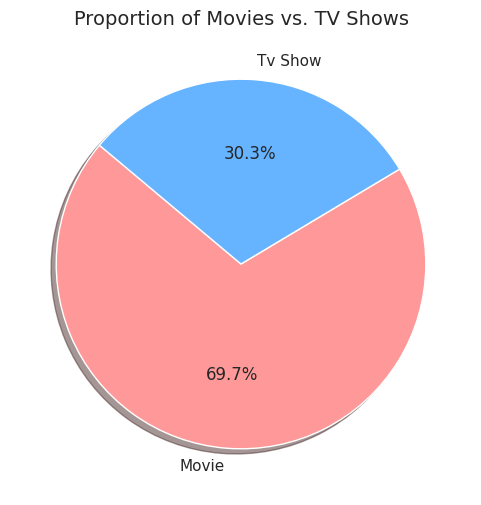

In [14]:
# Create a Pie Chart to visualize the proportions visually
plt.figure(figsize=(6, 6))
plt.pie(content_counts, labels=content_counts.index, autopct='%1.1f%%', 
        colors=['#ff9999', '#66b3ff'], startangle=140, shadow=True)
plt.title('Proportion of Movies vs. TV Shows', fontsize=14)
plt.show()

### Step 5: Summarize key findings

In [15]:
#Dynamically extract key metrics for the summary


total_titles=len(df)
majority_type=content_counts.idxmax()
majority_count=content_counts.max()
majority_pct=content_proportions.max()



print("\n=====================KEY FINDINGS======================")
print(f"1.Total Volume: The cleaned dataset contains a total of {total_titles} titles.")
print(f"2.Dominant Format: '{majority_type}' is the most common content type, "
     f"with {majority_count} titles.")
print(f"3.Proportion: '{majority_type}'s make up {majority_pct:.1f}% of the entire catalog, "
     f"indicating a strong focus on this format over others.")

print("======================================================")


=====================KEY FINDINGS======================
1.Total Volume: The cleaned dataset contains a total of 8790 titles.
2.Dominant Format: 'Movie' is the most common content type, with 6126 titles.
3.Proportion: 'Movie's make up 69.7% of the entire catalog, indicating a strong focus on this format over others.


## Task 3 – Country-Wise Netflix Content Analysis

### Description : Analyze Netflix content availability across different countries.

### Step 1: Extract and clean country information

In [16]:
df=pd.read_csv("/kaggle/input/datasets/fatmakaplan35/netflix-dataset/cleaned_dataset.csv")

In [17]:
df_countries=df.dropna(subset=['country'].copy())

In [18]:
df_countries['country']=df_countries['country'].str.split(',')
df_countries=df_countries.explode('country')

In [19]:
df_countries['country']=df_countries['country'].str.strip().str.title()

### Step 2: Calculate content count by country

In [20]:
country_counts=df_countries['country'].value_counts()

### Step 3: Identify top content-producting countries

In [21]:
## extract the top 10 countries

top_10_countries=country_counts.head(10)

print("--- Top 10 Content-Producting Countries ---")
print(top_10_countries)
print("-" * 42)

--- Top 10 Content-Producting Countries ---
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64
------------------------------------------


### Step 4: Create charts and rankings

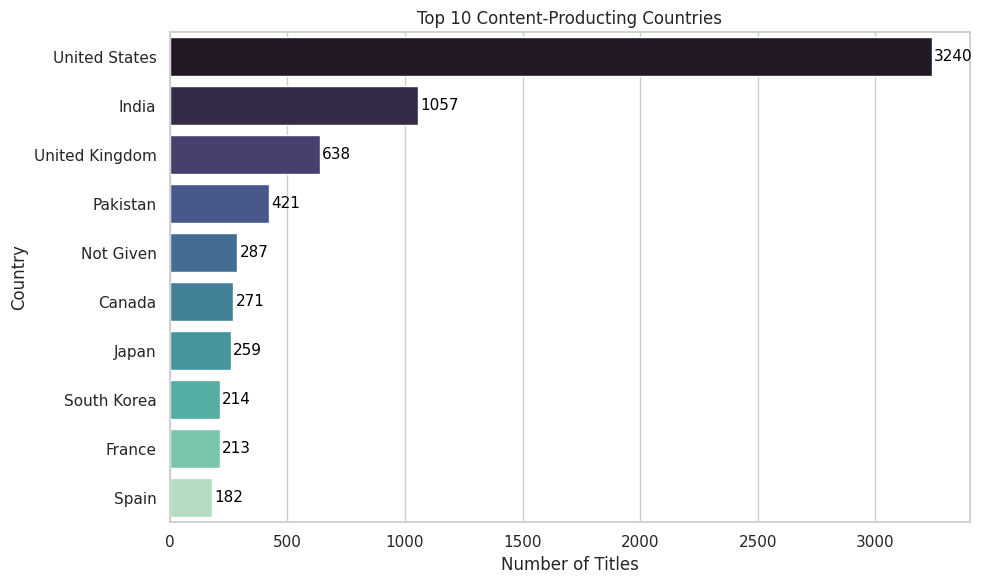

In [22]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))
ax=sns.barplot(x=top_10_countries.values , y=top_10_countries.index, palette="mako")


plt.title('Top 10 Content-Producting Countries')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)


# Add data labels to the end of each bar

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width() + 10 , p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, color='black')

plt.tight_layout()
plt.show()

### Step 5: Generate business insights

In [23]:
## Calculate dynamic metrics for insights

total_country_mentions=country_counts.sum()
top_country=country_counts.index[0]
top_count=country_counts.iloc[0]


top_country_pct=(top_count / total_country_mentions) * 100
top_3_pct=(country_counts.head(3).sum() / total_country_mentions) * 100


print("\n================== BUSINESS INSIGHTS ============")

print(f"1.Market Leader: '{top_country}' is the dominant content producer , contributing to {top_count} titles")
print(f"  (accounting for {top_country_pct: .1f}% of all global content contributions).\n")

print(f"2.Geographic Concentration: The top 3 countries alone produce {top_3_pct:.1f}% of the platform's catalog ,  ")
print(f"  indicating a highly centralized production strategy heavily reliant on a few key regions.\n")


print(f"3.International Collaborations: By seperating comma-delimited country data , we discovered")
print("    that a significant portion of titles are co-produced across borders , maximizing regional appeal.")
print("=========================================================")



================== BUSINESS INSIGHTS ============
1.Market Leader: 'United States' is the dominant content producer , contributing to 3240 titles
  (accounting for  36.9% of all global content contributions).

2.Geographic Concentration: The top 3 countries alone produce 56.1% of the platform's catalog ,  
  indicating a highly centralized production strategy heavily reliant on a few key regions.

3.International Collaborations: By seperating comma-delimited country data , we discovered
    that a significant portion of titles are co-produced across borders , maximizing regional appeal.


## Task 4 – Trend Analysis by Release Year

### Description : Analyze how Netflix content production has changed over time.

In [24]:
df=pd.read_csv("/kaggle/input/datasets/fatmakaplan35/netflix-dataset/cleaned_dataset.csv")

### Step 1: Organize content by release year

In [25]:
df_release=df.dropna(subset=['release_year']).copy()
df_release['release_year']=df_release['release_year'].astype(int)


df_recent=df_release[df_release['release_year'] >=2000]

### Step 2: Calculate yearly content releases

In [26]:
yearly_total=df_recent.groupby('release_year').size()

yearly_by_type= df_recent.groupby(['release_year' , 'type']).size().unstack(fill_value=0)

print("----- Yearly Content Releases (Recent Years) -----")
print(yearly_by_type.tail(10))
print("-" * 45)

----- Yearly Content Releases (Recent Years) -----
type          Movie  TV Show
release_year                
2012            173       63
2013            225       61
2014            264       88
2015            396      159
2016            658      243
2017            765      265
2018            767      379
2019            633      397
2020            517      436
2021            277      315
---------------------------------------------


### Step 3: Identify growth and decline trends

In [27]:
yearly_growth= yearly_total.pct_change() * 100


peak_year= yearly_total.idxmax()
peak_count = yearly_total.max()

print(f"\nPeak Release Year: {peak_year} with {peak_count} titles added/released.")



Peak Release Year: 2018 with 1146 titles added/released.


### Step 4: Create trend visualizations

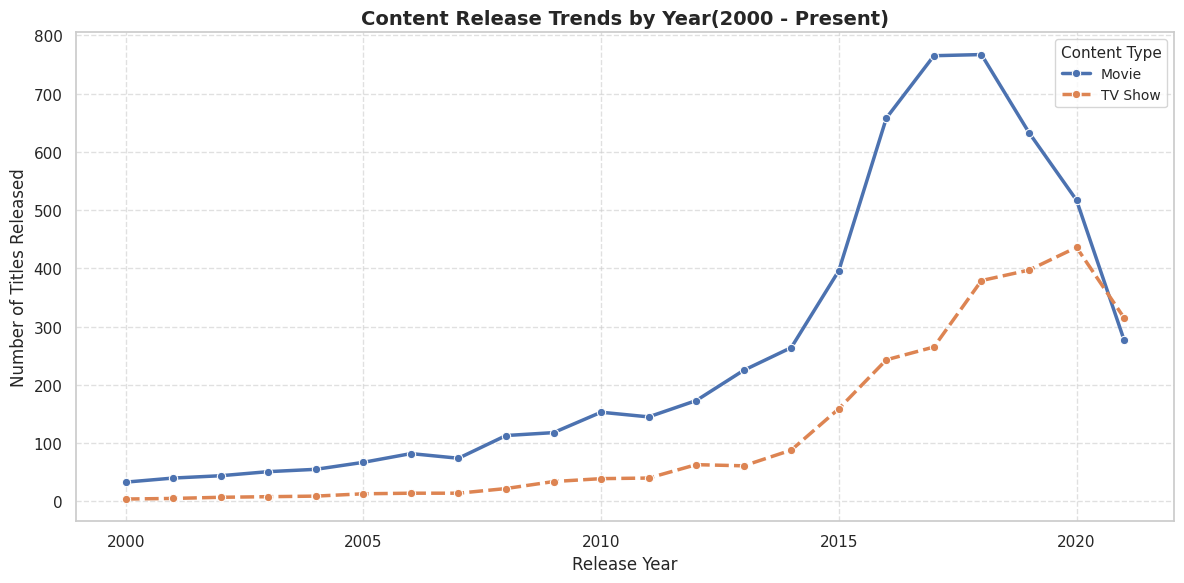

In [28]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))


sns.lineplot(data=yearly_by_type , linewidth=2.5 , marker="o")

plt.title('Content Release Trends by Year(2000 - Present)' , fontsize=14 , fontweight='bold')
plt.xlabel('Release Year' , fontsize=12)
plt.ylabel('Number of Titles Released' , fontsize=12)
plt.legend(title='Content Type' , title_fontsize='11' , fontsize='10')
plt.grid(True , linestyle='--' , alpha=0.6)

plt.tight_layout()
plt.show()

### Step 5: Interpret business patterns

In [29]:
movies_peak = yearly_by_type['Movie'].idxmax() if 'Movie' in yearly_by_type.columns else None
tv_peak = yearly_by_type['TV Show'].idxmax() if 'TV Show' in yearly_by_type.columns else None

print("\n================ BUSINESS PATTERNS & INSIGHTS ================")
print(f"1. Exponential Growth Era: Content production experienced significant growth starting around 2015, ")
print(f"   aligning with Netflix's aggressive global expansion and original content investments.")
print(f"2. Peak Production: Total catalog additions peaked in {peak_year} ({peak_count} titles), ")
print(f"   followed by a stabilization or decline influenced by licensing shifts and market saturation.")
print(f"3. Format Pivot: Movie additions peaked in {movies_peak}, whereas TV Show releases peaked in {tv_peak}, ")
print("   reflecting a strategic transition toward multi-season episodic content to maximize subscriber retention.")
print("==============================================================")


================ BUSINESS PATTERNS & INSIGHTS ================
1. Exponential Growth Era: Content production experienced significant growth starting around 2015, 
   aligning with Netflix's aggressive global expansion and original content investments.
2. Peak Production: Total catalog additions peaked in 2018 (1146 titles), 
   followed by a stabilization or decline influenced by licensing shifts and market saturation.
3. Format Pivot: Movie additions peaked in 2018, whereas TV Show releases peaked in 2020, 
   reflecting a strategic transition toward multi-season episodic content to maximize subscriber retention.


## Task 5 – Content Rating & Genre Analysis

### Description : Examine content ratings and genres to understand audience targeting.

### Step 1: Analyze rating categories.

In [30]:
df=pd.read_csv("/kaggle/input/datasets/fatmakaplan35/netflix-dataset/cleaned_dataset.csv")

In [31]:
df.rename(columns={'type': 'Type', 'rating': 'Rating', 'listed_in': 'Genre'}, inplace=True)

In [32]:
if 'listed_in' in df.columns and 'genre' not in df.columns:
    df.rename(columns={'listed_in': 'Genre'}, inplace=True)

In [33]:
df_ratings = df.dropna(subset=['Rating']).copy()
df_ratings['Rating'] = df_ratings['Rating'].str.strip().str.upper()

In [34]:
rating_counts = df_ratings['Rating'].value_counts()

print("--- Top Rating Categories ---")
print(rating_counts.head(10))
print("-" * 35)

--- Top Rating Categories ---
Rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64
-----------------------------------


## Task 5 – Content Rating & Genre Analysis

### Description : Examine content ratings and genres to understand audience targeting.

In [35]:
df=pd.read_csv("/kaggle/input/datasets/fatmakaplan35/netflix-dataset/cleaned_dataset.csv")

In [36]:
#Standardize column names if needed
if 'listed_in' in df.columns:
    df.rename(columns={'listed_in': 'Genre'} , inplace=True)


### Step 1: Analyze rating categories

In [37]:
df_ratings = df.dropna(subset=['rating']).copy()
df_ratings['rating']=df_ratings['rating'].str.strip().str.upper()

In [38]:
#Calculate rating frequencies
rating_counts = df_ratings['rating'].value_counts().reset_index()
rating_counts.columns = ['rating' , 'count']

In [39]:
print("---- Top Rating Categories-----")
print(rating_counts.head(10).to_string(index=False))
print("-" * 29)

---- Top Rating Categories-----
rating  count
 TV-MA   3205
 TV-14   2157
 TV-PG    861
     R    799
 PG-13    490
 TV-Y7    333
  TV-Y    306
    PG    287
  TV-G    220
    NR     79
-----------------------------


### Step 2: Identify the most common genres

In [40]:
#Handle multiple genres per title(e.g., "Action , Thriller")
df_genres = df.dropna(subset=['Genre']).copy()
df_genres['Genre'] = df_genres['Genre'].str.split(',')
df_genres = df_genres.explode('Genre')
df_genres['Genre'] = df_genres['Genre'].str.strip()

#Calculate genre frequencies

genre_counts= df_genres['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre' , 'Count']


print("\n---- Top 10 Content Genres")
print(genre_counts.head(10).to_string(index=False))
print("-" * 29)


---- Top 10 Content Genres
                   Genre  Count
    International Movies   2752
                  Dramas   2426
                Comedies   1674
  International TV Shows   1349
           Documentaries    869
      Action & Adventure    859
               TV Dramas    762
      Independent Movies    756
Children & Family Movies    641
         Romantic Movies    616
-----------------------------


### Step 3: Compare ratings across content types

In [41]:
#Cross-tabulate Content Type by Rating
type_rating_crosstab = pd.crosstab(df_ratings['rating'] , df_ratings['type'])

#Sort by total volume to show the most relevant comparisons first
type_rating_crosstab['Total'] = type_rating_crosstab.sum(axis=1)
type_rating_crosstab = type_rating_crosstab.sort_values(by='Total' , ascending=False).drop(columns='Total')


print("\n--- Ratings by Content Type (Top Categories) ---")
print(type_rating_crosstab.head(10))
print("-" * 48)


--- Ratings by Content Type (Top Categories) ---
type    Movie  TV Show
rating                
TV-MA    2062     1143
TV-14    1427      730
TV-PG     540      321
R         797        2
PG-13     490        0
TV-Y7     139      194
TV-Y      131      175
PG        287        0
TV-G      126       94
NR         75        4
------------------------------------------------


### Step 4: Create interactive visualizations

In [42]:
df = pd.read_csv('/kaggle/input/datasets/fatmakaplan35/netflix-dataset/cleaned_dataset.csv')

df.rename(columns={'type': 'Type', 'rating': 'Rating', 'listed_in': 'Genre', 'country': 'Country'}, inplace=True)

df_genres = df.dropna(subset=['Genre']).copy()
df_genres['Genre'] = df_genres['Genre'].str.split(',')
df_genres = df_genres.explode('Genre')
df_genres['Genre'] = df_genres['Genre'].str.strip()

genre_counts = df_genres['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']
top_15_genres = genre_counts.head(15)['Genre']


df_top_genres = df_genres[df_genres['Genre'].isin(top_15_genres)]


fig_bar = px.histogram(
    df_top_genres,
    y='Genre',
    color='Type', 
    orientation='h',
    title='<b>Top 15 Genres by Content Type</b>',
    barmode='group',
    category_orders={"Genre": top_15_genres.tolist()[::-1]} 
)
fig_bar.update_layout(yaxis_title="Genre Category", xaxis_title="Total Titles", template='plotly_white')
fig_bar.show()

### Step 5: Present audience insights

In [43]:
top_rating = rating_counts.iloc[0]['rating']
top_rating_pct = (rating_counts.iloc[0]['count'] / len(df_ratings)) * 100
top_genre = genre_counts.iloc[0]['Genre']

print("\n================ AUDIENCE & CONTENT INSIGHTS ================")
print(f"1. Target Audience: The catalog is heavily weighted toward '{top_rating}' content, ")
print(f"   which makes up {top_rating_pct:.1f}% of the library, signaling a focus on mature/adult demographics.")
print(f"2. Genre Anchors: '{top_genre}' is the most produced genre overall, providing a reliable ")
print("   baseline for subscriber engagement and algorithmic recommendations.")
print("3. Format Segmentation: Movies show a wider spread across broad genres (Comedies, Dramas), ")
print("   while TV Shows concentrate deeply on highly bingeable categories (International, Crime, Kids).")
print("==============================================================")


================ AUDIENCE & CONTENT INSIGHTS ================
1. Target Audience: The catalog is heavily weighted toward 'TV-MA' content, 
   which makes up 36.5% of the library, signaling a focus on mature/adult demographics.
2. Genre Anchors: 'International Movies' is the most produced genre overall, providing a reliable 
   baseline for subscriber engagement and algorithmic recommendations.
3. Format Segmentation: Movies show a wider spread across broad genres (Comedies, Dramas), 
   while TV Shows concentrate deeply on highly bingeable categories (International, Crime, Kids).


## Task 6 – Netflix Business Insights Report
### Description : Create a comprehensive business intelligence report from the netflix dataset


In [44]:
df = pd.read_csv("/kaggle/input/datasets/fatmakaplan35/netflix-dataset/cleaned_dataset.csv")

In [45]:
df.rename(columns={'type': 'Type', 'rating': 'Rating', 'listed_in': 'Genre', 'country': 'Country'}, inplace=True)

### # Step 1 & 2: Complete EDA & Pattern Identification

In [46]:
type_counts = df['Type'].value_counts()

In [47]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year.dropna().astype(int)
trend_data = df[df['year_added'] >= 2010].groupby(['year_added', 'Type']).size().unstack(fill_value=0)

In [48]:
df_countries = df.dropna(subset=['Country']).copy()
df_countries['Country'] = df_countries['Country'].str.split(',')
df_countries = df_countries.explode('Country')
df_countries['Country'] = df_countries['Country'].str.strip()
top_countries = df_countries['Country'].value_counts().head(10)

In [49]:
df_genres = df.dropna(subset=['Genre']).copy()
df_genres['Genre'] = df_genres['Genre'].str.split(',')
df_genres = df_genres.explode('Genre')
df_genres['Genre'] = df_genres['Genre'].str.strip()
top_genres = df_genres['Genre'].value_counts().head(10)

### Step 3: Develop Visual Dashboards

In [50]:
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "domain"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=(
        "Content Distribution (Movies vs TV Shows)", 
        "Content Addition Trend (2010-Present)",
        "Top 10 Producing Countries", 
        "Top 10 Genres Overall"
    ),
    horizontal_spacing=0.15,
    vertical_spacing=0.15
)

# Panel 1: Pie Chart (Content Type)
fig.add_trace(
    go.Pie(labels=type_counts.index, values=type_counts.values, 
           marker_colors=['#E50914', '#221F1F'], textinfo='label+percent', hole=0.4),
    row=1, col=1
)

# Panel 2: Line Chart (Trends)
if 'Movie' in trend_data.columns:
    fig.add_trace(go.Scatter(x=trend_data.index, y=trend_data['Movie'], mode='lines+markers', name='Movies', line=dict(color='#E50914')), row=1, col=2)
if 'TV Show' in trend_data.columns:
    fig.add_trace(go.Scatter(x=trend_data.index, y=trend_data['TV Show'], mode='lines+markers', name='TV Shows', line=dict(color='#564d4d')), row=1, col=2)

# Panel 3: Horizontal Bar Chart (Countries)
fig.add_trace(
    go.Bar(x=top_countries.values[::-1], y=top_countries.index[::-1], orientation='h', marker_color='#E50914', showlegend=False),
    row=2, col=1
)

# Panel 4: Horizontal Bar Chart (Genres)
fig.add_trace(
    go.Bar(x=top_genres.values[::-1], y=top_genres.index[::-1], orientation='h', marker_color='#221F1F', showlegend=False),
    row=2, col=2
)

# Update layout for a clean, professional look
fig.update_layout(
    title_text="<b>Netflix Global Content Strategy Dashboard</b>",
    title_font_size=24,
    height=900,
    width=1200,
    template="plotly_white",
    hovermode="closest"
)

# Display the dashboard
fig.show()

### # Step 4 & 5: Generate Actionable Insights & Final Report

In [51]:
total_titles = len(df)
movie_pct = (type_counts.get('Movie', 0) / total_titles) * 100
tv_pct = (type_counts.get('TV Show', 0) / total_titles) * 100
top_country = top_countries.index[0]
top_genre = top_genres.index[0]

report = f"""
================================================================================
                    NETFLIX BUSINESS INTELLIGENCE REPORT
================================================================================

EXECUTIVE SUMMARY:
This report analyzes a cleaned dataset of {total_titles:,} titles to evaluate 
Netflix's global content acquisition and production strategy.

1. FORMAT STRATEGY (MOVIES VS. TV SHOWS)
   - Movies account for {movie_pct:.1f}% of the catalog, while TV Shows make up {tv_pct:.1f}%.
   - INSIGHT: While movies dominate the historical volume, trend data reveals 
     a strategic pivot. The gap between new Movies and TV Shows has narrowed 
     in recent years, reflecting a shift toward multi-season, retention-driving 
     episodic content.

2. GLOBAL PRODUCTION & LOCALIZATION
   - {top_country} is the undisputed leader in content generation. 
   - INSIGHT: The heavy reliance on {top_country}, India, and the UK highlights 
     the core subscriber bases. However, the high volume of "International Movies" 
     and "International TV Shows" indicates aggressive localization to capture 
     emerging markets outside North America.

3. GENRE DEMAND & TARGETING
   - '{top_genre}' and 'Comedies' are the foundational pillars of the library.
   - INSIGHT: Netflix relies on broadly appealing, narrative-driven genres to 
     maintain its baseline subscriber engagement. Niche genres are supplemented 
     through international acquisitions rather than in-house original production.

4. GROWTH TRAJECTORY
   - Content acquisition peaked between 2018-2021 before plateauing.
   - INSIGHT: The platform has transitioned from an "aggressive expansion" phase 
     (prioritizing quantity and licensing) to a "profitability and curation" phase, 
     focusing on higher-margin original content.

STRATEGIC RECOMMENDATIONS:
- Prioritize TV Show renewals over mid-tier movie acquisitions to boost 
  month-over-month subscriber retention.
- Diversify production hubs beyond the US and UK to mitigate regional market 
  saturation and appeal to high-growth markets in LATAM and APAC.
================================================================================
"""

print(report)


                    NETFLIX BUSINESS INTELLIGENCE REPORT

EXECUTIVE SUMMARY:
This report analyzes a cleaned dataset of 8,790 titles to evaluate 
Netflix's global content acquisition and production strategy.

1. FORMAT STRATEGY (MOVIES VS. TV SHOWS)
   - Movies account for 69.7% of the catalog, while TV Shows make up 30.3%.
   - INSIGHT: While movies dominate the historical volume, trend data reveals 
     a strategic pivot. The gap between new Movies and TV Shows has narrowed 
     in recent years, reflecting a shift toward multi-season, retention-driving 
     episodic content.

2. GLOBAL PRODUCTION & LOCALIZATION
   - United States is the undisputed leader in content generation. 
   - INSIGHT: The heavy reliance on United States, India, and the UK highlights 
     the core subscriber bases. However, the high volume of "International Movies" 
     and "International TV Shows" indicates aggressive localization to capture 
     emerging markets outside North America.

3. GENRE DEMAND &